# Reviewing the Liar's Poker Solvers

This notebook uses one tiny game throughout so every operation remains quick and inspectable.

- **FSP** repeatedly computes a best response and mixes it into an average policy.
- **CFR** updates regrets for every information set and returns its average strategy.
- **CFR+** uses alternating updates, non-negative regrets, and linear average-strategy weighting.

For exact evaluation, `predicted_avg` is the average win rate of a best response across both seats. The transformed exploitability plotted in this repo is `2 * predicted_avg - 1`, which approaches zero at equilibrium.

In [1]:
import os, sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "liars_poker").is_dir() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from liars_poker.core import GameSpec
from liars_poker.env import Env, Rules
from liars_poker.infoset import CALL, InfoSet
from liars_poker.policies.tabular_dense import DenseTabularPolicy
from liars_poker.algo.br_exact_dense_to_dense import best_response_dense
from liars_poker.algo.cfr_exact_dense import CFRExactDense
from liars_poker.algo.cfr_plus_dense import CFRPlusDense
from liars_poker.training.dense_fsp import dense_fsp_loop
from liars_poker.eval.match import eval_seats_split

spec = GameSpec(
    ranks=2,
    suits=2,
    hand_size=1,
    claim_kinds=("RankHigh", "Pair"),
    suit_symmetry=True,
)
rules = Rules(spec)
print(spec)
print("Claims:", [rules.render_action(a) for a in range(len(rules.claims))])

GameSpec(ranks=2, suits=2, hand_size=1, claim_kinds=('RankHigh', 'Pair'), suit_symmetry=True)
Claims: ['RankHigh:1', 'RankHigh:2', 'Pair:1', 'Pair:2']


## 1. Environment basics

`Env` deals private hands, tracks the public claim history, enforces increasing claims, and resolves `CALL`. P1 always acts first.

In [2]:
env = Env(spec)
obs = env.reset(hands=((1,), (2,)))
print("Opening observation:", obs)

claim = rules.parse_action("RankHigh:1", legal=obs["legal_actions"])
obs = env.step(claim)
print("After claim:", rules.render_action(claim), obs)

obs = env.step(CALL)
print("After CALL:", obs)

Opening observation: {'to_play': 'P1', 'hand': (1,), 'last_claim_idx': None, 'legal_actions': [0, 1, 2, 3], 'history': (), 'terminal': False, 'winner': None, 'infoset_key': InfoSet(pid=0, hand=(1,), history=())}
After claim: RankHigh:1 {'to_play': 'P2', 'hand': (2,), 'last_claim_idx': 0, 'legal_actions': [-1, 1, 2, 3], 'history': (0,), 'terminal': False, 'winner': None, 'infoset_key': InfoSet(pid=1, hand=(2,), history=(0,))}
After CALL: {'to_play': 'P2', 'hand': (2,), 'last_claim_idx': 0, 'legal_actions': [], 'history': (0, -1), 'terminal': True, 'winner': 'P1', 'infoset_key': InfoSet(pid=1, hand=(2,), history=(0, -1))}


## 2. Dense policies and exact evaluation

`DenseTabularPolicy.S[hid, hand_idx, action_col]` stores a complete strategy. A newly created dense policy is uniform over legal actions.

`best_response_dense` computes the exact best response in both seats. It is also the main correctness metric used during exact training.

In [3]:
uniform_policy = DenseTabularPolicy(spec)
opening_infoset = InfoSet(pid=0, hand=(1,), history=())
print("Uniform opening strategy:")
for action, probability in uniform_policy.action_probs(opening_infoset).items():
    print(f"  {rules.render_action(action):12s} {probability:.3f}")

def exact_score(policy):
    _, meta = best_response_dense(spec, policy, store_state_values=False)
    p_first, p_second = meta["computer"].exploitability()
    predicted_avg = 0.5 * (p_first + p_second)
    return {
        "br_as_p1": p_first,
        "br_as_p2": p_second,
        "predicted_avg": predicted_avg,
        "exploitability": 2.0 * predicted_avg - 1.0,
    }

pd.Series(exact_score(uniform_policy), name="uniform policy")

Uniform opening strategy:
  RankHigh:1   0.250
  RankHigh:2   0.250
  Pair:1       0.250
  Pair:2       0.250


br_as_p1          0.861111
br_as_p2          0.750000
predicted_avg     0.805556
exploitability    0.611111
Name: uniform policy, dtype: float64

In [13]:
uniform_policy

DenseTabularPolicy(spec=GameSpec(ranks=2, suits=2, hand_size=1, claim_kinds=('RankHigh', 'Pair'), suit_symmetry=True), k=4, hands=2)

## 3. Historical context: dense FSP

Dense FSP starts from a policy, repeatedly computes an exact best response, and posterior-correctly mixes that response into the running average. It was the main training approach before CFR and CFR+ were added.

In [5]:
fsp_policy, fsp_logs = dense_fsp_loop(
    spec,
    episodes=5,
    episodes_test=2000,
    efficient=True,
)

pd.DataFrame(fsp_logs["exploitability_series"])[
    ["predicted_avg", "p_first", "p_second", "rollout_avg"]
]

Predicted exploitability: avg=0.805555556 (first=0.8611, second=0.7500)
Sampled exploitability: avg=0.8115 (BR as P1=0.8650, BR as P2=0.7580), chi2 p-value=0.7484

Predicted exploitability: avg=0.767361110 (first=0.8333, second=0.7014)
Sampled exploitability: avg=0.7745 (BR as P1=0.8340, BR as P2=0.7150), chi2 p-value=0.6069

Predicted exploitability: avg=0.678240740 (first=0.7778, second=0.5787)
Sampled exploitability: avg=0.6840 (BR as P1=0.7900, BR as P2=0.5780), chi2 p-value=0.6605

Predicted exploitability: avg=0.633680556 (first=0.7500, second=0.5174)
Sampled exploitability: avg=0.6365 (BR as P1=0.7590, BR as P2=0.5140), chi2 p-value=0.7186

Predicted exploitability: avg=0.612500002 (first=0.7444, second=0.4806)
Sampled exploitability: avg=0.6055 (BR as P1=0.7390, BR as P2=0.4720), chi2 p-value=0.6611



,predicted_avg,p_first,p_second,rollout_avg
0,0.805556,0.861111,0.750000,0.8115
1,0.767361,0.833333,0.701389,0.7745
2,0.678241,0.777778,0.578704,0.6840
3,0.633681,0.750000,0.517361,0.6365
4,0.612500,0.744444,0.480556,0.6055


## 4. CFR versus CFR+

Both solvers maintain regrets and cumulative strategy sums over the complete dense game.

CFR updates both players from the same current strategy. CFR+ updates players alternately, clips cumulative regrets at zero, and weights later strategies more heavily.

In [6]:
cfr = CFRExactDense(spec)
cfr_plus = CFRPlusDense(spec)

print("CFR strategy tensor:", cfr.S.shape)
print("CFR regret tensor:", cfr.R0.shape)
print("CFR+ starts at iteration:", cfr_plus.iteration)

cfr.iterate()
cfr_plus.iterate()
print("After one iteration, CFR+ iteration:", cfr_plus.iteration)
print("Maximum CFR regret:", float(cfr.R0.max()))
print("Minimum CFR+ regret:", float(cfr_plus.R0.min()), "(CFR+ floors regrets at zero)")

CFR strategy tensor: (16, 2, 5)
CFR regret tensor: (16, 2, 5)
CFR+ starts at iteration: 0
After one iteration, CFR+ iteration: 1
Maximum CFR regret: 1.6666666666666667
Minimum CFR+ regret: 0.0 (CFR+ floors regrets at zero)


In [7]:
def train_with_checkpoints(solver, checkpoints=(1, 5, 20, 100)):
    records = []
    for iteration in range(1, max(checkpoints) + 1):
        solver.iterate()
        if iteration in checkpoints:
            records.append({"iteration": iteration, **exact_score(solver.average_policy())})
    return solver.average_policy(), pd.DataFrame(records)

cfr_policy, cfr_results = train_with_checkpoints(CFRExactDense(spec))
cfr_plus_policy, cfr_plus_results = train_with_checkpoints(CFRPlusDense(spec))

comparison = pd.concat(
    [cfr_results.assign(algorithm="CFR"), cfr_plus_results.assign(algorithm="CFR+")],
    ignore_index=True,
)
comparison[["algorithm", "iteration", "br_as_p1", "br_as_p2", "exploitability"]]

,algorithm,iteration,br_as_p1,br_as_p2,exploitability
0,CFR,1,0.861111,0.750000,0.611111
1,CFR,5,0.716667,0.453889,0.170556
2,CFR,20,0.679167,0.363472,0.042639
3,CFR,100,0.669167,0.339361,0.008528
4,CFR+,1,0.861111,0.750000,0.611111
5,CFR+,5,0.768724,0.425255,0.193980
6,CFR+,20,0.668254,0.431207,0.099461
7,CFR+,100,0.666733,0.342217,0.008950


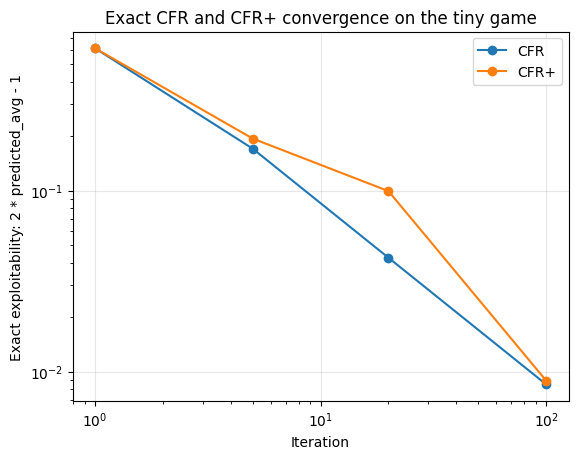

In [8]:
for algorithm, group in comparison.groupby("algorithm"):
    plt.plot(group["iteration"], group["exploitability"], marker="o", label=algorithm)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Exact exploitability: 2 * predicted_avg - 1")
plt.title("Exact CFR and CFR+ convergence on the tiny game")
plt.grid(alpha=0.3)
plt.legend();

## 5. Inspect and empirically evaluate trained policies

Exact exploitability is the strongest small-game metric. Sampled matches remain useful for checking concrete seat-specific behavior and for evaluating games that are too large for exact best response.

In [10]:
opening_rows = {}
for name, policy in {
    "FSP": fsp_policy,
    "CFR": cfr_policy,
    "CFR+": cfr_plus_policy,
}.items():
    opening_rows[name] = {
        rules.render_action(action): probability
        for action, probability in policy.action_probs(opening_infoset).items()
    }
print(opening_infoset)
pd.DataFrame(opening_rows).fillna(0.0)

InfoSet(pid=0, hand=(1,), history=())


,FSP,CFR,CFR+
RankHigh:1,0.208333,0.005833,0.029836
RankHigh:2,0.708333,0.983833,0.969743
Pair:1,0.041667,0.007833,0.000371
Pair:2,0.041667,0.002500,0.000050


In [ ]:
exact_summary = pd.DataFrame(
    {
        "FSP": exact_score(fsp_policy),
        "CFR": exact_score(cfr_policy),
        "CFR+": exact_score(cfr_plus_policy),
    }
).T

sampled_cfr_vs_plus = eval_seats_split(
    spec,
    cfr_policy,
    cfr_plus_policy,
    episodes=2_000,
    seed=7,
)

display(exact_summary)
print("Sampled CFR vs CFR+ seat split:", sampled_cfr_vs_plus)

## What to use next

- Use `DenseTabularPolicy` and `best_response_dense` to inspect or exactly evaluate manageable games.
- Use `CFRPlusDense` as the strongest current exact training baseline.
- Use `eval_seats_split` for empirical seat-specific comparisons.
- Use the benchmark scripts for long checkpointed runs.

The key scaling limitation is that dense policies and exact CFR allocate the full `2^k` public-state space. A future sampled or neural CFR implementation should first be validated against the exact results produced here.